<div style="display: flex; align-items: center; justify-content: center; gap: 20px;">
    <img src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_webp,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F17becea5-db12-4465-be92-858de78b9137_319x253.png" alt="Image Gauche" style="width: 200px; height: auto;">
    <div style="font-size: 26px; text-align: center;">
        <h1>
            <span style="font-weight: bold; color:#6dce64; text-decoration: underline;">
                Conversion rate project
            </span>
        </h1>
    </div>
    <img src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_webp,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F17becea5-db12-4465-be92-858de78b9137_319x253.png" alt="Image Droite" style="width: 200px; height: auto;">
</div>

<h1 style="font-size: 18px; text-align: center; font-style: italic;">
    <span style="font-weight: bold; color:#6dce64">
        Student : Loic VALENTINI
    </span>
</h1>

<h1 style="font-size: 18px; font-weight: bold;">
    Project Goal:
</h1>
<p style="font-size: 18px; font-style: italic;">
    Using the conversion_data_train.csv file which details a Y/N conversion based on features (such as country, age, new_user, source, and total_pages_visited), develop the best predictive model using unsupervised machine learning techniques. The model's performance will primarily be evaluated using the F1-score, although additional metrics like accuracy and recall may also be considered to inform further decisions.
</p>


# 1. Retriveing data


In [47]:
# Classic libraires import for analysis

import numpy as np
import pandas as pd

In [48]:
# Data collection

data = pd.read_csv('../src/conversion_data_train.csv')

# 2. Prerequisites for Machine Learning Performance

<h1 style="font-size: 18px;">
    First, all models and preprocessing steps are implemented in separate Python scripts.<br>
    Second, the dataset is consistently split into 80% for training and 20% for testing, using a fixed random state (0) to ensure reproducibility.<br>
    Third, all parameters and evaluation metrics are tracked locally using an MLflow server.<br>
    Finally, model selection is based on the F1-score measured on the test set, although all relevant metrics are logged for further analysis.
</h1>





# 3. Baseline model - Univariate logistic regression


<h1 style="font-size: 18px;">
    Since the target variable is categorical (converted: 0 or 1), we initially choose to use the simplest model : univariate logistic regression.  
    Standard parameters will be applied, and a single feature that appears highly impactful (total_pages_visited) will be used.
</h1>


In [49]:
# Launch Baseline model

%run logisticregression_models/Model_0.py

Data successfully retrieved

X and Y successfully created

Train-test split successfully done

Training data successfully standardized

Test data successfully standardized

Baseline model successfully trained


2025/05/28 12:59:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


F1-score on train set:  0.6990580847723705
F1-score on test set:  0.6792929292929293


In [50]:
# Mlflow check

import threading
import os

def start_mlflow_ui():
    os.system("mlflow ui --port 5000")

thread = threading.Thread(target=start_mlflow_ui)
thread.start()

print("✅ MLflow UI lancé sur http://localhost:5000 (ouvrir dans le navigateur)")


✅ MLflow UI lancé sur http://localhost:5000 (ouvrir dans le navigateur)


<h1 style="font-size: 18px;">
    The baseline model achieves an F1-score of around 0.7 which is a good starting point. Let's attempt to improve it by incorporating all the features.
</h1>


# 4. Multivariate logistic regression models

## 4a. Model1


After integrating only one feature (total_pages_visited) in Model 0, we now incorporate all available features from the dataset to improve the F1-score, along with a simple preprocessing pipeline using StandardScaler and OneHotEncoder.

In [51]:
# Launch Model1

%run -i logisticregression_models/Model_1.py

2025/05/28 12:59:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


The F1-score has significantly improved by integrating all features, reaching 0.766 on the training set and 0.755 on the test set.

Let’s now experiment with three alternative simple preprocessings: 
- (1) removing the traffic_source feature due to its low impact on the target (Model 2), 
- (2) removing age outliers (Model 3),
- (3) applying both of these adjustments simultaneously (Model 4).


## 4b. Model2, 3 and 4

In [52]:
# Launch Model2

%run -i logisticregression_models/Model_2.py

2025/05/28 12:59:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [53]:
# Launch Model3

%run -i logisticregression_models/Model_3.py

2025/05/28 12:59:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [54]:
# Launch Model4

%run -i logisticregression_models/Model_4.py

2025/05/28 12:59:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


The performance of all these models is quite similar, with F1-scores on the test set ranging from 0.754 to 0.756. Given the best score and the simplification it provides, preprocessing #4 is recommended moving forward.

## 4c. Model5

Model 5 uses preprocessing #4 and applies a Logistic Regression. The objective is to determine the optimal decision threshold—defaulting to 0.5—by iterating over values between 0.2 and 0.8 with a step of 0.01.

Reminder: The threshold is the probability above which the model classifies an instance as 1 (converted). For example, with a threshold of 0.5, predictions below 0.5 are labeled as 0, and those equal to or above 0.5 are labeled as 1.

In [55]:
# Launch Model5

%run -i logisticregression_models/Model_5.py


Model successfully trained
Test with Threshold = 0.2
Test with Threshold = 0.21000000000000002
Test with Threshold = 0.22000000000000003
Test with Threshold = 0.23000000000000004
Test with Threshold = 0.24000000000000005
Test with Threshold = 0.25000000000000006
Test with Threshold = 0.26000000000000006
Test with Threshold = 0.2700000000000001
Test with Threshold = 0.2800000000000001
Test with Threshold = 0.2900000000000001
Test with Threshold = 0.3000000000000001
Test with Threshold = 0.3100000000000001
Test with Threshold = 0.3200000000000001
Test with Threshold = 0.3300000000000001
Test with Threshold = 0.34000000000000014
Test with Threshold = 0.35000000000000014
Test with Threshold = 0.36000000000000015
Test with Threshold = 0.37000000000000016
Test with Threshold = 0.38000000000000017
Test with Threshold = 0.3900000000000002
Test with Threshold = 0.4000000000000002
Test with Threshold = 0.4100000000000002
Test with Threshold = 0.4200000000000002
Test with Threshold = 0.430000000

2025/05/28 12:59:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


This threshold adjustment yields a slight but meaningful improvement, with an F1-score of 0.774. We will keep this configuration and now explore feature engineering by introducing additional features.

## 4d. Model6

Model 6 uses the threshold of 0.38. Different combinations of feature engineering will be tested. The new columns to be tested are:
<ul>
<li>Grouping countries by continent: Europe, Asia, America</li>
<li>Grouping total_pages_visited into very_low, low, medium, high</li>
<li>Grouping ages into young, medium, old</li>
<li>Adding calculated columns: age * tpv, age / tpv, tpv / age</li>
<li>Adding powers: age², age³, age⁻¹, tpv², tpv³, apv⁻¹</li>
<li>There are 12 possible features to add, resulting in 4096 possible combinations. We will test 500 of them (randomly) to find the best combination and performances.</li>
</ul>

Note : tpv means total_pages_visited

In [56]:
# Launch Model6 - specific preprocessing included in the model

%run logisticregression_models/Model_6.py

Data successfully retrieved
Column 'source' successfully dropped
Removed 1017 outliers on 'age' (outside [5.76, 55.36])
[1/500] | F1 test: 0.7734 | Best F1 so far: 0.7734
[2/500] | F1 test: 0.7741 | Best F1 so far: 0.7741
[3/500] | F1 test: 0.7717 | Best F1 so far: 0.7741
[4/500] | F1 test: 0.7729 | Best F1 so far: 0.7741
[5/500] | F1 test: 0.7739 | Best F1 so far: 0.7741
[6/500] | F1 test: 0.7742 | Best F1 so far: 0.7742
[7/500] | F1 test: 0.7724 | Best F1 so far: 0.7742
[8/500] | F1 test: 0.7739 | Best F1 so far: 0.7742
[9/500] | F1 test: 0.7740 | Best F1 so far: 0.7742
[10/500] | F1 test: 0.7740 | Best F1 so far: 0.7742
[11/500] | F1 test: 0.7740 | Best F1 so far: 0.7742
[12/500] | F1 test: 0.7738 | Best F1 so far: 0.7742
[13/500] | F1 test: 0.7734 | Best F1 so far: 0.7742
[14/500] | F1 test: 0.7735 | Best F1 so far: 0.7742
[15/500] | F1 test: 0.7733 | Best F1 so far: 0.7742
[16/500] | F1 test: 0.7726 | Best F1 so far: 0.7742
[17/500] | F1 test: 0.7725 | Best F1 so far: 0.7742
[18/5

2025/05/28 13:05:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


With 500 possible combinations, the best one yielded an F1-score that is virtually identical (rounded to 0.01, it's still 0.77) to the one obtained previously (without feature engineering). Consequently, to keep things simple, no feature engineering will be applied moving forward.

## 4e. Model7

Model 7 keeps the threshold of 0.38 and no additional feature engineering. 

However, in this case, we aim to determine the optimal C hyperparameter in combination with the penalty hyperparameter using GridSearchCV with CV=5. The values [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 0.8, 1, 1.2, 1.5, 2, 5, 10, 20, 50, 100] will be tested for C, and [l1, l2] for the penalty.

Reminder: The C parameter controls the strength of regularization in Logistic Regression (where the default value is C=1). The penalty specifies the type of regularization applied (l1 = Lasso, l2 = Ridge).

Note: The solver must be set to liblinear to allow testing both penalty parameters.

In [57]:
# Launch Model7

%run -i logisticregression_models/Model_7.py


Best hyperparameters :  {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best validation f1 :  0.763814478232897


2025/05/28 13:06:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Fortunately, we identified the optimal parameters. However, the resulting F1-score is slightly lower than that of Model 5.
Therefore, Model 5 remains our best-performing model so far.

# 5. Decision Tree models

After configuring logistic regression, let's explore whether a decision tree model could enhance performance.

## 5a. Model8

We will implement our first decision tree using the multivariate model, without further feature engineering (deemed irrelevant in our previous steps), and apply a simple GridSearchCV to determine the best parameters. The threshold decision is kept to 0.38.

In [58]:
# Launch Model8

%run -i decisiontree_models/Model_8.py

Best hyperparameters :  {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best validation f1 :  0.9856380868415252


2025/05/28 13:33:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


At this stage, performance is still below that of logistic regression. Let's see if an Optuna search can help improve the results.

## 5c. Model9

Model 9 is similar, but instead of using GridSearchCV, we will apply an Optuna study with a broader range of hyperparameters. 100 trials will be performed.

In [60]:
# Launch Model9

%run -i decisiontree_models/Model_9.py

[I 2025-05-28 13:43:22,917] A new study created in memory with name: no-name-5713a6a2-173e-4ee8-a90e-d5ccf9ad5860
[I 2025-05-28 13:43:23,110] Trial 0 finished with value: 0.7444138353229263 and parameters: {'max_depth': 54, 'min_samples_split': 9, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.7444138353229263.
[I 2025-05-28 13:43:23,288] Trial 1 finished with value: 0.7455765710799268 and parameters: {'max_depth': 22, 'min_samples_split': 9, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.7455765710799268.
[I 2025-05-28 13:43:23,449] Trial 2 finished with value: 0.7477781182960466 and parameters: {'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.7477781182960466.
[I 2025-05-28 13:43:23,618] Trial 3 finished with value: 0.7459492509935799 and parameters: {'max_depth': 60, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.7477781182960466.
[I 2025-05-28 13:43:23,772] Trial 4 finished with value: 0.74

Despite all these computations, performance remains inferior to logistic regression. Let's check whether adjusting the decision threshold can make a difference.

## 5d. Model10

Let's try to find the optimal decision threshold for the slightly enhanced Decision Tree model.

In [64]:
# Launch Model10

%run -i decisiontree_models/Model_10.py


Model successfully trained
Test with Threshold = 0.2
Test with Threshold = 0.21
Test with Threshold = 0.22
Test with Threshold = 0.23
Test with Threshold = 0.24
Test with Threshold = 0.25
Test with Threshold = 0.26
Test with Threshold = 0.27
Test with Threshold = 0.28
Test with Threshold = 0.29
Test with Threshold = 0.3
Test with Threshold = 0.31
Test with Threshold = 0.32
Test with Threshold = 0.33
Test with Threshold = 0.34
Test with Threshold = 0.35
Test with Threshold = 0.36
Test with Threshold = 0.37
Test with Threshold = 0.38
Test with Threshold = 0.39
Test with Threshold = 0.4
Test with Threshold = 0.41
Test with Threshold = 0.42
Test with Threshold = 0.43
Test with Threshold = 0.44
Test with Threshold = 0.45
Test with Threshold = 0.46
Test with Threshold = 0.47
Test with Threshold = 0.48
Test with Threshold = 0.49
Test with Threshold = 0.5
Test with Threshold = 0.51
Test with Threshold = 0.52
Test with Threshold = 0.54
Test with Threshold = 0.55
Test with Threshold = 0.56
Test

2025/05/28 13:54:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


The best decision threshold was found to be 0.36. However, even with this adjustment, the model's performance remains lower than that of logistic regression.

## 5e. Model11

Model11 aims to re-performing Model 9 (optuna optimization) but using criterion "entropy" instead of "gini"

Note : Gini measures impurity based on misclassification probability, while entropy measures uncertainty or disorder.

In [66]:
# Launch Model11

%run -i decisiontree_models/Model_11.py

[I 2025-05-28 14:11:34,205] A new study created in memory with name: no-name-cabf3efa-6646-4aa1-babc-1f95e6bb21e4
[I 2025-05-28 14:11:34,348] Trial 0 finished with value: 0.7435740514075887 and parameters: {'max_depth': 56, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.7435740514075887.
[I 2025-05-28 14:11:34,466] Trial 1 finished with value: 0.7366471133065761 and parameters: {'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.7435740514075887.
[I 2025-05-28 14:11:34,609] Trial 2 finished with value: 0.747333130143249 and parameters: {'max_depth': 66, 'min_samples_split': 12, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.747333130143249.
[I 2025-05-28 14:11:34,753] Trial 3 finished with value: 0.7455765710799268 and parameters: {'max_depth': 83, 'min_samples_split': 11, 'min_samples_leaf': 10}. Best is trial 2 with value: 0.747333130143249.
[I 2025-05-28 14:11:34,885] Trial 4 finished with value: 0.748

Once again, the performance falls short compared to previous models. Let's explore whether adjusting the decision threshold can help improve the results in this case.

## 5f. Model12

In [68]:
# Launch Model12

%run -i decisiontree_models/Model_12.py


Model successfully trained
Test with Threshold = 0.2
Test with Threshold = 0.21
Test with Threshold = 0.22
Test with Threshold = 0.23
Test with Threshold = 0.24
Test with Threshold = 0.25
Test with Threshold = 0.26
Test with Threshold = 0.27
Test with Threshold = 0.28
Test with Threshold = 0.29
Test with Threshold = 0.3
Test with Threshold = 0.31
Test with Threshold = 0.32
Test with Threshold = 0.33
Test with Threshold = 0.34
Test with Threshold = 0.35
Test with Threshold = 0.36
Test with Threshold = 0.37
Test with Threshold = 0.38
Test with Threshold = 0.39
Test with Threshold = 0.4
Test with Threshold = 0.41
Test with Threshold = 0.42
Test with Threshold = 0.43
Test with Threshold = 0.44
Test with Threshold = 0.45
Test with Threshold = 0.46
Test with Threshold = 0.47
Test with Threshold = 0.48
Test with Threshold = 0.49
Test with Threshold = 0.5
Test with Threshold = 0.51
Test with Threshold = 0.52
Test with Threshold = 0.54
Test with Threshold = 0.55
Test with Threshold = 0.56
Test

2025/05/28 14:16:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Despite adjusting the decision threshold, the best performance achieved with the Gini criterion is an F1-score of 0.76. As a result, we will no longer consider this option moving forward.

# 6. RandomForest models

While Decision Trees do not outperform logistic regression in our case, ensemble methods like Random Forest—which aggregate the predictions of multiple decision trees—may offer improved performance. Let's give it a try!

## 6a. Model13

Model13 represents our first attempt using a Random Forest classifier. We rely on Optuna to explore the hyperparameter space and identify the optimal configuration. As in previous experiments, the decision threshold is fixed at 0.38, the gini criterion is used for node splitting, and no feature engineering is applied. A total of 100 trials will be run to maximize the F1-score.

In [70]:
# Launch Model13

%run -i randomforest_models/Model_13.py

[I 2025-05-28 14:27:42,395] A new study created in memory with name: no-name-eb4c45e3-c621-4c90-85af-528a06dc50e1
[I 2025-05-28 14:27:47,772] Trial 0 finished with value: 0.7607433217189314 and parameters: {'n_estimators': 93, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.7607433217189314.
[I 2025-05-28 14:27:52,458] Trial 1 finished with value: 0.754325259515571 and parameters: {'n_estimators': 79, 'max_depth': 33, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.7607433217189314.
[I 2025-05-28 14:27:58,302] Trial 2 finished with value: 0.7565846599131694 and parameters: {'n_estimators': 88, 'max_depth': 26, 'min_samples_split': 9, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.7607433217189314.
[I 2025-05-28 14:28:04,860] Trial 3 finished with value: 0.7609953703703703 and parameters: {'n_estimators': 98, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 3 with value: 0.7

At this stage, performance remains lower than what we achieved with Logistic Regression. Despite leveraging ensemble learning and automated hyperparameter optimization, the Random Forest model does not yet outperform. This suggests that either the data lacks the complexity needed to benefit from this type of model or further tuning and feature enhancements are required.

## 6b. Model14

Once again, let's attempt to fine-tune the decision threshold to see if we can extract better performance from the model. Sometimes, even slight adjustments in thresholding can significantly impact metrics like the F1-score.

In [72]:
# Launch Model14

%run -i randomforest_models/Model_14.py


Model successfully trained
Test with Threshold = 0.2
Test with Threshold = 0.21
Test with Threshold = 0.22
Test with Threshold = 0.23
Test with Threshold = 0.24
Test with Threshold = 0.25
Test with Threshold = 0.26
Test with Threshold = 0.27
Test with Threshold = 0.28
Test with Threshold = 0.29
Test with Threshold = 0.3
Test with Threshold = 0.31
Test with Threshold = 0.32
Test with Threshold = 0.33
Test with Threshold = 0.34
Test with Threshold = 0.35
Test with Threshold = 0.36
Test with Threshold = 0.37
Test with Threshold = 0.38
Test with Threshold = 0.39
Test with Threshold = 0.4
Test with Threshold = 0.41
Test with Threshold = 0.42
Test with Threshold = 0.43
Test with Threshold = 0.44
Test with Threshold = 0.45
Test with Threshold = 0.46
Test with Threshold = 0.47
Test with Threshold = 0.48
Test with Threshold = 0.49
Test with Threshold = 0.5
Test with Threshold = 0.51
Test with Threshold = 0.52
Test with Threshold = 0.54
Test with Threshold = 0.55
Test with Threshold = 0.56
Test

2025/05/28 14:43:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Once again, the measured F1-score remains lower than that of the Logistic Regression models. Therefore, we will discontinue efforts on the Random Forest approach and shift our focus to exploring other, potentially more effective methods.

# 7. Boosting Models

## 7a. Model15

Let's now explore AdaBoost, an ensemble technique that builds a strong classifier by combining multiple weak learners. We will apply it using Logistic Regression as the base estimator, since it remains our most performant model so far. The goal is to determine whether boosting can enhance the overall performance beyond what we've achieved with a single Logistic model.

In [75]:
# Launch Model15

%run -i boosting_models/Model_15.py

Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\valen\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Best params: {'adaboostclassifier__learning_rate': 0.1, 'adaboostclassifier__n_estimators': 200}
Best F1 score: 0.7447262683478261


c:\Users\valen\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
2025/05/28 15:09:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


AdaBoost did not deliver strong results. Let’s now try XGBoost — however, the outcome is also disappointing, with an F1-score of just 0.60.

## 7b. Model16

Let’s now explore XGBoost, a powerful gradient boosting technique known for its performance and efficiency. We will apply it using a Logistic Regression base approach to assess whether this advanced boosting method can surpass the results previously obtained with a standalone Logistic model.

In [76]:
# Launch Model16

%run -i boosting_models/Model_16.py

Fitting 3 folds for each of 48 candidates, totalling 144 fits


c:\Users\valen\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:25:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 50}
Best F1 score: 0.7646462293174067


2025/05/28 15:25:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


The performance is decent, with an F1-score of 0.766, but not an improvement over previous models. Let's attempt to optimize it further by identifying the best decision threshold.

## 7c. Model17

In [78]:
# Launch Model17

%run -i boosting_models/Model_17.py

c:\Users\valen\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:44:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model successfully trained
Test with Threshold = 0.2
Test with Threshold = 0.21
Test with Threshold = 0.22
Test with Threshold = 0.23
Test with Threshold = 0.24
Test with Threshold = 0.25
Test with Threshold = 0.26
Test with Threshold = 0.27
Test with Threshold = 0.28
Test with Threshold = 0.29
Test with Threshold = 0.3
Test with Threshold = 0.31
Test with Threshold = 0.32
Test with Threshold = 0.33
Test with Threshold = 0.34
Test with Threshold = 0.35
Test with Threshold = 0.36
Test with Threshold = 0.37
Test with Threshold = 0.38
Test with Threshold = 0.39
Test with Threshold = 0.4
Test with Threshold = 0.41
Test with Threshold = 0.42
Test with Threshold = 0.43
Test with Threshold = 0.44
Test with Threshold = 0.45
Test with Threshold = 0.46
Test with Threshold = 0.47
Test with Threshold = 0.48
Test with Threshold = 0.49
Test with Threshold = 0.5
Test with Threshold = 0.51
Test with Threshold = 0.52
Test with Threshold = 0.54
Test with Threshold = 0.55
Test with Threshold = 0.56
Test

c:\Users\valen\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:44:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2025/05/28 15:44:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Aside from logistic regression models, this is the best-performing model so far, achieving an F1-score of 0.770 with an optimal threshold set at 0.34.

# 8. Stacking and voting models

At this stage, our best individual models are Model 5 (Logistic Regression), Model 10 (Decision Tree), and Model 17 (XGBoost using Logistic Regression as base). To further enhance performance, we will now attempt to combine them using a stacking ensemble approach. This method leverages the strengths of each model by using their predictions as input for a final meta-model.

## 8a. Model18


In [82]:
# Launch Model18

%run -i stacking_voting_models/Model_18.py

✅ Best threshold: 0.21, F1: 0.7738


2025/05/28 19:31:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


The stacking ensemble achieves a performance similar to that of logistic regression alone — which already provides strong results. As a next step, let’s experiment with a voting ensemble method to see if combining model predictions differently can yield further improvements.

## 8b. Model19

We will now apply a similar approach, but this time using a soft voting ensemble method, which averages predicted probabilities from each model to make the final decision.

In [85]:
# Launch Model19

%run -i stacking_voting_models/Model_19.py

✅ Best threshold: 0.37, F1: 0.7712


2025/05/28 19:37:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


With an F1-score of 0.771, the result is decent but remains quite similar to the best outcomes already obtained with logistic regression—without showing any significant improvement.

## 8c. Model20

To be thorough, let's reintroduce the first preprocessing (which includes all the original features) to assess whether ensemble methods, starting with stacking, perform better under these conditions.

In [86]:
# Launch Model20

%run -i stacking_voting_models/Model_20.py

✅ Best threshold: 0.31, F1: 0.7650


2025/05/28 19:41:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


As expected, performance is lower. Let's now test the voting method using the full set of features as well.

## 8d. Model21

In [87]:
# Launch Model21

%run -i stacking_voting_models/Model_21.py

✅ Best threshold: 0.33, F1: 0.7630


2025/05/28 19:44:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Once again, performance is lower. As a final step, let's explore a simple deep learning approach (neural network) to broaden our perspective.

# 9. Deep learning model

## 9a. Model22

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

1773/1773 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step
✅ Best threshold: 0.32, F1: 0.7695
7090/7090 ━━━━━━━━━━━━━━━━━━━━ 4s 535us/step


2025/05/28 20:06:56 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/05/28 20:07:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


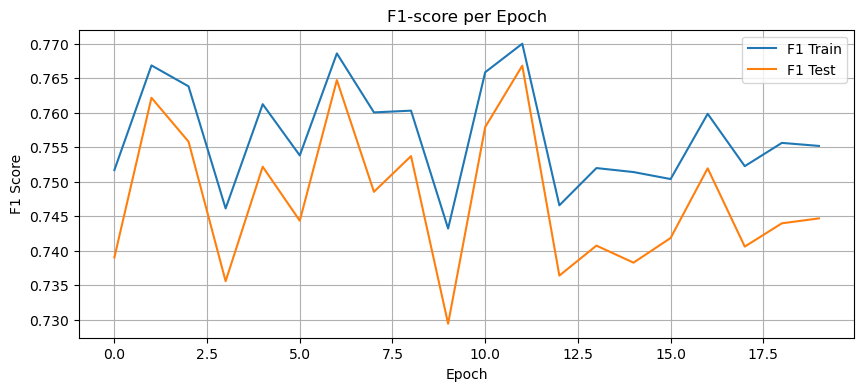

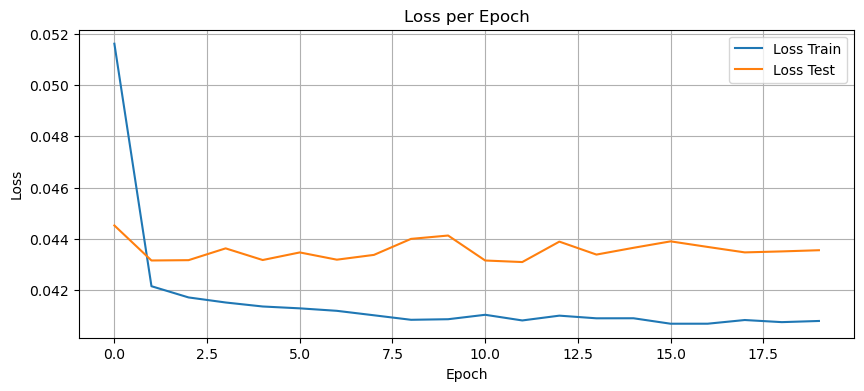

In [93]:
# Launch Model22

%run -i deep_learning_model/Model_22.py

This simple deep learning model does not outperform the baseline models in this particular case. Moreover, the training process does not lead to any significant performance improvement.

# 10. Conclusion

- The best performance in terms of **F1-score** on the test set was achieved by **Model 5**, a simple multivariate logistic regression.
- This score was nearly matched by ensemble methods such as **stacking** and **voting**, but without a clear improvement.
- Even a basic **deep learning** model did not significantly outperform the simpler approaches.
- Given the current results, the **logistic regression model** remains the best choice for production: it is interpretable, fast to train, lightweight, and yields solid performance:
  - **F1-score**: 0.77  
  - **Precision**: 0.81  
  - **Recall**: 0.73

- Of course, additional optimizations could be explored—such as alternative **feature engineering** or more extensive **cross-validation**—but the most promising avenue for improvement would likely be the **integration of new and relevant features**. For instance:
  - more detailed user-related data (e.g., gender, geolocation),
  - temporal features (e.g., hour of the day, day of the week),
  - technical/contextual data (e.g., device type, number of clicks before conversion).

These could help capture more complex patterns and ultimately improve the model’s ability to predict conversions.
